# 🫀Heart Disease Dataset - Exploratory Data Analysis (EDA)🩺

## 📌 1. Introduction

### 📖 Project Overview
Heart disease is one of the leading causes of death worldwide. This project performs an Exploratory Data Analysis (EDA) on the Heart Disease dataset to understand the characteristics of patients, identify important patterns, analyze feature distributions, handle missing values, and explore relationships between different clinical attributes.

### 🎯 Objective of the Analysis
The main objectives of this analysis are:
- To understand the structure and quality of the dataset.
- To identify and handle missing values and data inconsistencies.
- To explore the distribution of each feature using visualizations.
- To analyze the relationship between different features and heart disease.
- To identify the most important factors associated with heart disease.
- To summarize key insights that can be useful for building machine learning models.

## 2. IMPORT LIBRARIES
- **Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. LOAD DATASET

In [105]:
df=pd.read_csv('heart_disease.csv')

## 4. DATASET OVERVIEW

### 📂 Dataset Information
- **Dataset:** Heart Disease Dataset
- **Total Records:** 920
- **Target Variable:** `num` (Heart Disease Presence)

In [106]:
df.sample(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
383,384,46,Male,Hungary,non-anginal,120.0,230.0,False,normal,150.0,False,0.0,NaN,NaN,NaN,0
519,520,54,Male,Hungary,asymptomatic,125.0,216.0,False,normal,140.0,False,0.0,NaN,NaN,NaN,1
199,200,59,Male,Cleveland,typical angina,160.0,273.0,False,lv hypertrophy,125.0,False,0.0,upsloping,0.0,normal,1
727,728,60,Male,VA Long Beach,non-anginal,180.0,0.0,False,st-t abnormality,140.0,True,1.5,flat,NaN,NaN,0
97,98,60,Female,Cleveland,asymptomatic,150.0,258.0,False,lv hypertrophy,157.0,False,2.6,flat,2.0,reversable defect,3


In [107]:
df.shape

(920, 16)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [109]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [110]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [111]:
df.isna().sum()[df.isna().sum()>0].sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64

In [112]:
print(f'No of duplicate Values = {df.duplicated().sum()}')

No of duplicate Values = 0


In [113]:
print('Max Age = ',df['age'].max())
print('Min Age = ',df['age'].min())
print('Avg Age = ',df['age'].mean().round(2))

Max Age =  77
Min Age =  28
Avg Age =  53.51


## 5. UNIVARIATE ANALYSIS

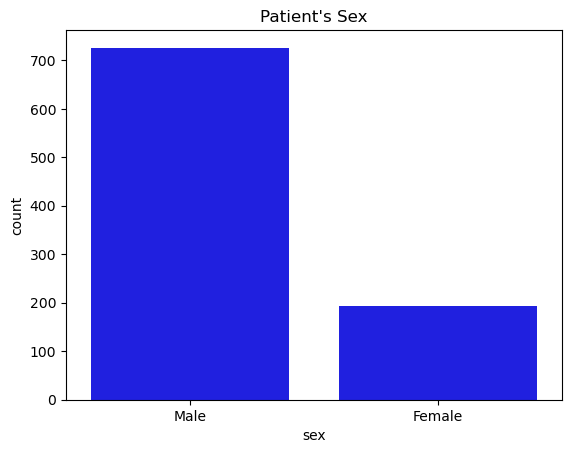

In [114]:
sns.countplot(x=df['sex'],color='blue')
plt.title("Patient's Sex")
plt.show()

In [115]:
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

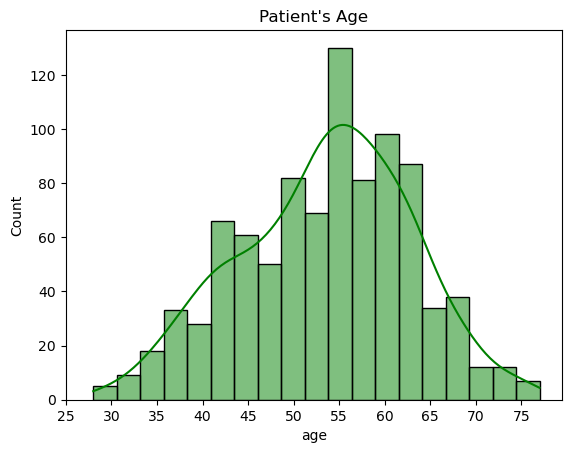

In [116]:
sns.histplot(df['age'],kde=True,color='green')
plt.xticks(range(25,80,5))
plt.title("Patient's Age")
plt.show()

In [117]:
print("Male percentage = ",((df['sex']=='Male').sum()/920*100).round(2),"%")
print('Female percentage = ',((df['sex']=='Female').sum()/920*100).round(2),"%")

Male percentage =  78.91 %
Female percentage =  21.09 %


In [118]:
df['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

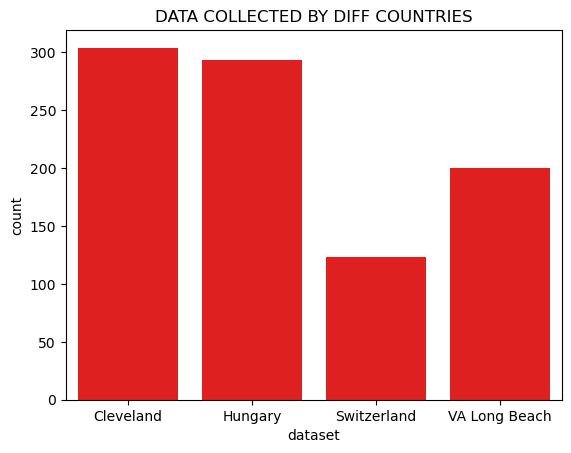

In [119]:
sns.countplot(data=df,x='dataset',color='red')
plt.title("DATA COLLECTED BY DIFF COUNTRIES")
plt.show()

In [120]:
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

In [121]:
print("Most data has been collected from =",df['dataset'].value_counts().idxmax())

Most data has been collected from = Cleveland


In [122]:
df['cp'].unique()

array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object)

In [123]:
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

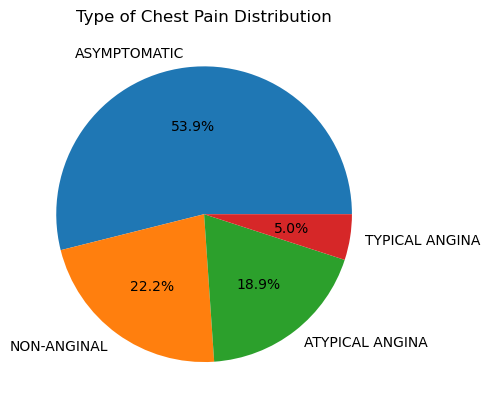

In [124]:
plt.pie(df['cp'].value_counts(),labels=df['cp'].value_counts().index.str.upper(),autopct='%1.1f%%')
plt.title("Type of Chest Pain Distribution")
plt.show()

In [125]:
print(f'Typical angina patient = {(df['cp']=='typical angina').sum()/920*100:.2f}%')
print(f'Atypical angina patient = {(df['cp']=='atypical angina').sum()/920*100:.2f}%')
print(f'Non-Anginal patient = {(df['cp']=='non-anginal').sum()/920*100:.2f}%')
print(f'Asymptomatic patient = {(df['cp']=='asymptomatic').sum()/920*100:.2f}%\n')
print("'Most Patient has No Chest Pain'")

Typical angina patient = 5.00%
Atypical angina patient = 18.91%
Non-Anginal patient = 22.17%
Asymptomatic patient = 53.91%

'Most Patient has No Chest Pain'


In [126]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


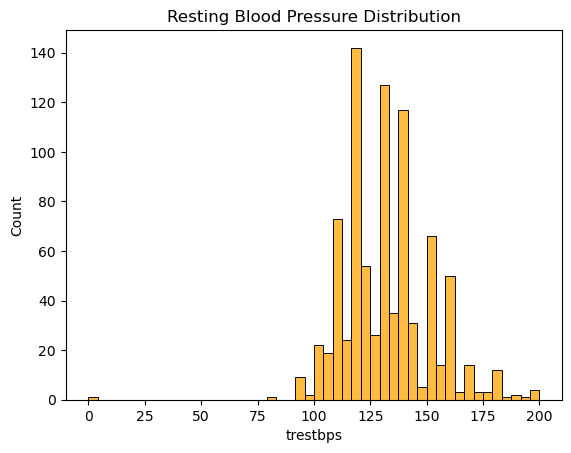

In [127]:
sns.histplot(data=df,x='trestbps',color='orange')
plt.title("Resting Blood Pressure Distribution")
plt.show()

In [128]:
print('TrestBps = Blood pressure of the patient while resting\nNormal resting blood pressure is = 120 mm Hg\nHigher blood pressure(Hypertension)\n')
print(f"Average Resting blood pressure = {df['trestbps'].mean():.2f}")
print(f"Most Pateint's Resting bloodpressure = {df['trestbps'].mode()[0]}")
print("CONCLUSION\nMost patient's has Normal Blood Pressure")

TrestBps = Blood pressure of the patient while resting
Normal resting blood pressure is = 120 mm Hg
Higher blood pressure(Hypertension)

Average Resting blood pressure = 132.13
Most Pateint's Resting bloodpressure = 120.0
CONCLUSION
Most patient's has Normal Blood Pressure


In [129]:
print("Normal Cholestrol level < 200 mg/dl")

Normal Cholestrol level < 200 mg/dl


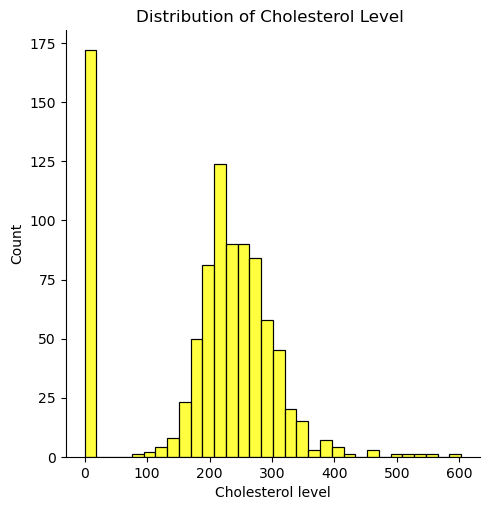

In [130]:
sns.displot(data=df,x='chol',color='yellow')
plt.title('Distribution of Cholesterol Level ')
plt.xlabel('Cholesterol level')
plt.show()

In [131]:
(df['chol']==0).sum()

np.int64(172)

In [132]:
df['chol'].describe()

count    890.000000
mean     199.130337
std      110.780810
min        0.000000
25%      175.000000
50%      223.000000
75%      268.000000
max      603.000000
Name: chol, dtype: float64

In [133]:
print(f"Fasting Blood Pressure > 120 mg/dl [True = 'Diabetes']\nFasting Blood Pressure < 120 mg/dl [False = 'Normal']")

Fasting Blood Pressure > 120 mg/dl [True = 'Diabetes']
Fasting Blood Pressure < 120 mg/dl [False = 'Normal']


In [134]:
print(f'Patient May have Diabetes = {(df['fbs']==True).sum()}')

Patient May have Diabetes = 138


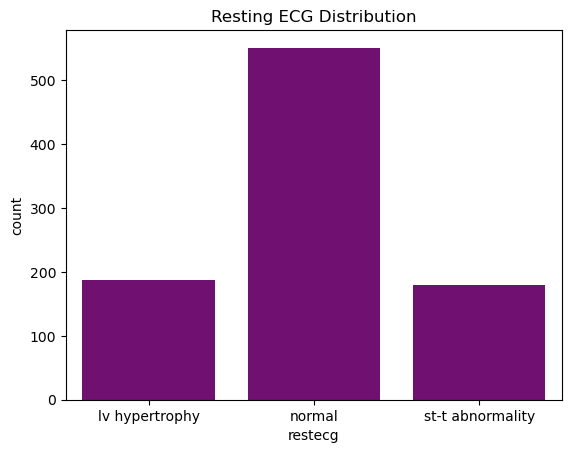

In [135]:
sns.countplot(x=df['restecg'],color='purple')
plt.title("Resting ECG Distribution")
plt.show()

In [136]:
print(f'Patient having Normal Rest ECG = {(df['restecg']=='normal').sum()}')
print(f'Patient having Abnoraml Rest ECG = {(df['restecg']=='st-t abnormality').sum()}')
print(f'Patient having LVH Rest ECG = {(df['restecg']=='lv hypertrophy').sum()}')

Patient having Normal Rest ECG = 551
Patient having Abnoraml Rest ECG = 179
Patient having LVH Rest ECG = 188


In [137]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [138]:
print(f"Patient Having Chest pain due to exercise = {(df['exang']==True).sum()}")
print(f"\nConclusion\nMost Patient does not suffer any Chest pain during Exercises")

Patient Having Chest pain due to exercise = 337

Conclusion
Most Patient does not suffer any Chest pain during Exercises


In [139]:
print(f"Patient having Higher risk of Heart disease = {((df['oldpeak']>2) & (df['slope']=='downsloping')).sum()}")

Patient having Higher risk of Heart disease = 27


In [140]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 6. BIVARIATE ANALYSIS

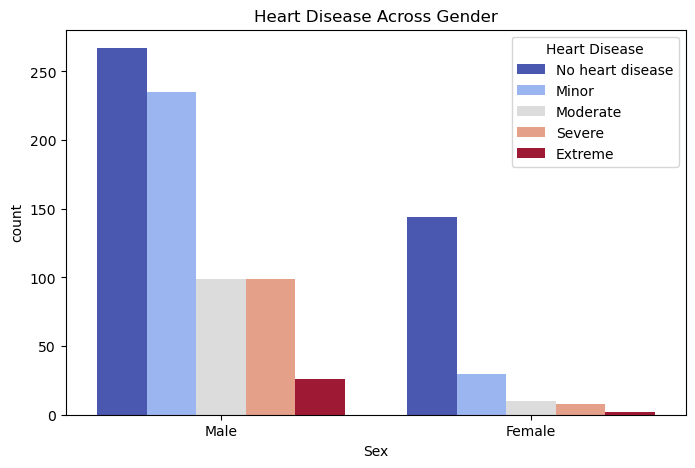

In [141]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='sex',hue='num',palette='coolwarm')
plt.title('Heart Disease Across Gender')
plt.legend(title='Heart Disease',labels=['No heart disease','Minor','Moderate','Severe','Extreme'])
plt.xlabel('Sex')
plt.show()

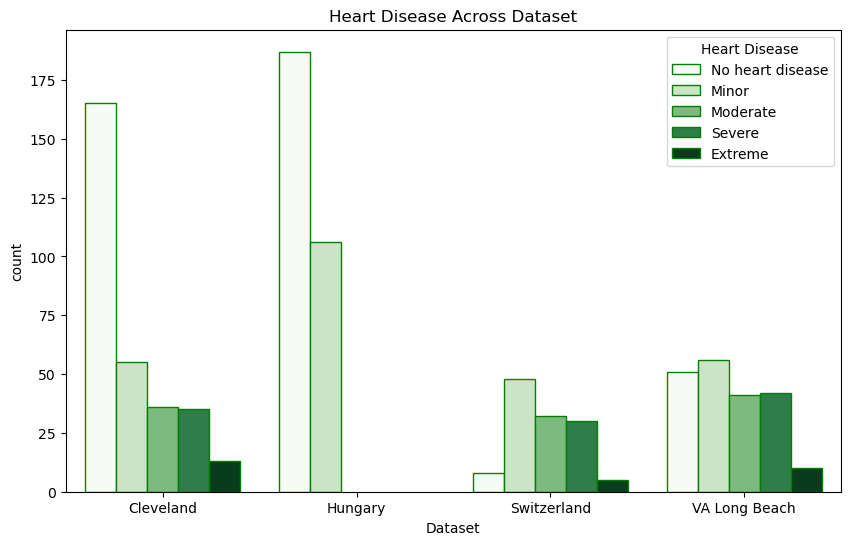

In [142]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='dataset',hue='num',palette='Greens',edgecolor='green')
plt.legend(title='Heart Disease',labels=['No heart disease','Minor','Moderate','Severe','Extreme'])
plt.title('Heart Disease Across Dataset')
plt.xlabel('Dataset')
plt.show()

In [143]:
dataset_disease=pd.crosstab(df['dataset'],df['num'],normalize='index').mul(100).round(2)

In [144]:
dataset_disease

num,0,1,2,3,4
dataset,,,,,
Cleveland,54.28,18.09,11.84,11.51,4.28
Hungary,63.82,36.18,0.00,0.00,0.00
Switzerland,6.50,39.02,26.02,24.39,4.07
VA Long Beach,25.50,28.00,20.50,21.00,5.00


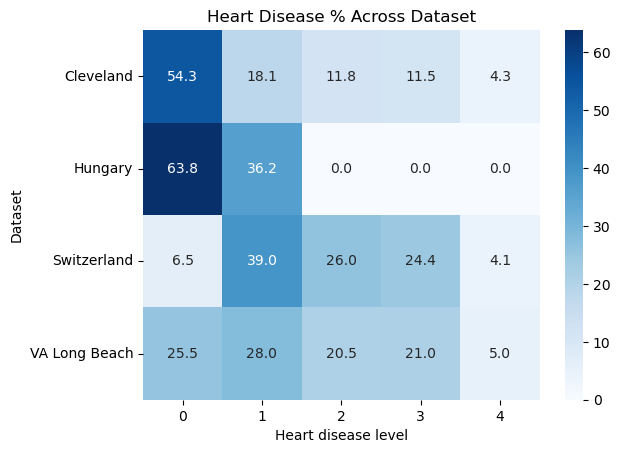

In [145]:
sns.heatmap(dataset_disease,annot=True,cmap='Blues',fmt='.1f')
plt.title('Heart Disease % Across Dataset')
plt.xlabel('Heart disease level')
plt.ylabel('Dataset')
plt.show()

In [146]:
contri=df['dataset'].value_counts(normalize=True).mul(100).round(2)

In [147]:
contri

dataset
Cleveland        33.04
Hungary          31.85
VA Long Beach    21.74
Switzerland      13.37
Name: proportion, dtype: float64

In [148]:
print(f"DATASET CONTRIBUTION\n\nClevelnad Contribution = {contri.iloc[0]}%\nHungary Contribution = {contri.iloc[1]}%")
print(f"VA Long Beach Contribution = {contri.iloc[2]}%\nSwitzerland Contribution = {contri.iloc[3]}%")

DATASET CONTRIBUTION

Clevelnad Contribution = 33.04%
Hungary Contribution = 31.85%
VA Long Beach Contribution = 21.74%
Switzerland Contribution = 13.37%


In [149]:
print(f"{dataset_disease.iloc[0,0]}% of patient has no heart disease in Cleveland")
print(f"No patient has any Mojor heart disease(2-4) in Hungary")
print(f"{100-(dataset_disease.iloc[2,0])}% of patient in Switzeland has some form of heart disease ")

54.28% of patient has no heart disease in Cleveland
No patient has any Mojor heart disease(2-4) in Hungary
93.5% of patient in Switzeland has some form of heart disease 


In [150]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


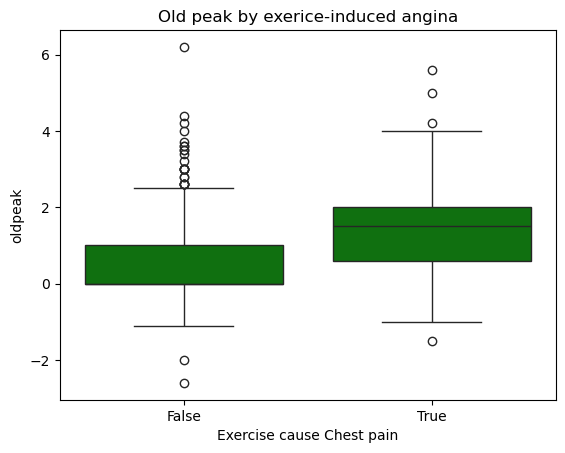

In [151]:
sns.boxplot(data=df,x='exang',y='oldpeak',color='green')
plt.title('Old peak by exerice-induced angina')
plt.xlabel('Exercise cause Chest pain')
plt.show()

In [152]:
print(f"People Having Chest Pain Due To Exercise Has Higher Old Peak")

People Having Chest Pain Due To Exercise Has Higher Old Peak


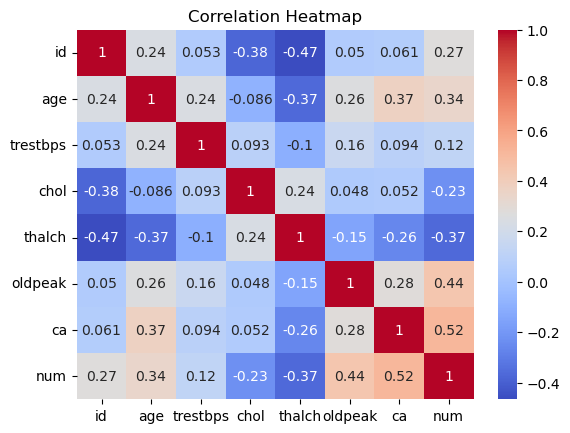

In [153]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 7.MISSING VALUE HANDLING

In [154]:
df['trestbps']=df['trestbps'].replace(0,np.nan)
df['trestbps']=df['trestbps'].fillna(df['trestbps'].median())

In [155]:
print(f'{(((df['chol']==0).sum())/920*100).round(2)}% of Patient has 0 cholesterol level which is not medically possible.So I am taking those values as missing values')

18.7% of Patient has 0 cholesterol level which is not medically possible.So I am taking those values as missing values


In [156]:
df['chol']=df['chol'].replace(0,np.nan)

In [157]:
df['chol']=df['chol'].fillna(df['chol'].median())

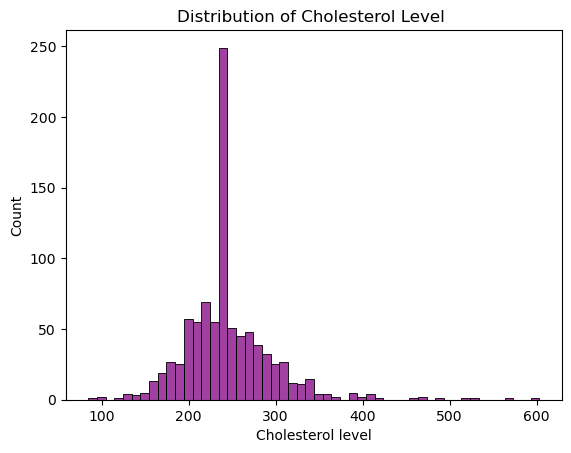

In [158]:
sns.histplot(data=df,x='chol',color='purple')
plt.title('Distribution of Cholesterol Level ')
plt.xlabel('Cholesterol level')
plt.show()

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [160]:
df['fbs']=df['fbs'].fillna(df['fbs'].mode()[0])

C:\Users\HP\AppData\Local\Temp\ipykernel_15348\3866412167.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs']=df['fbs'].fillna(df['fbs'].mode()[0])


In [161]:
df['restecg']=df['restecg'].fillna(df['restecg'].mode()[0])

In [162]:
df['thalch']=df['thalch'].fillna(df['thalch'].mean())

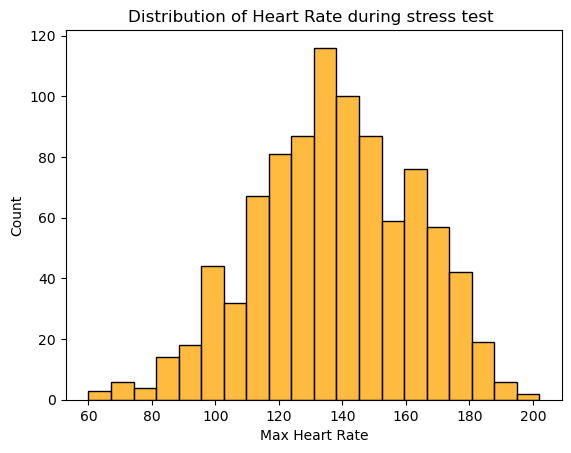

In [163]:
sns.histplot(data=df,x='thalch',color='orange')
plt.title('Distribution of Heart Rate during stress test ')
plt.xlabel('Max Heart Rate')
plt.show()

In [164]:
df['exang']=df['exang'].fillna(df['exang'].mode()[0])

C:\Users\HP\AppData\Local\Temp\ipykernel_15348\1431663488.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang']=df['exang'].fillna(df['exang'].mode()[0])


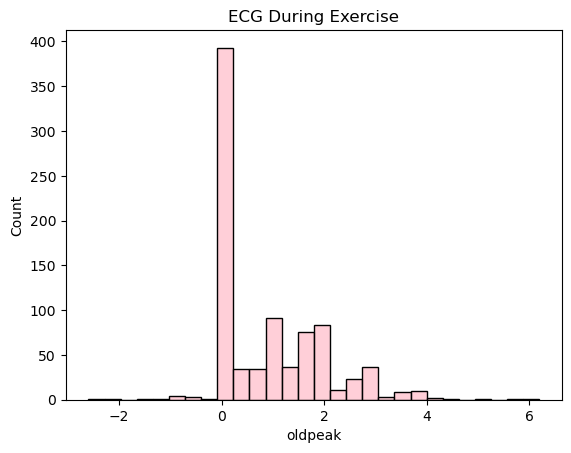

In [165]:
sns.histplot(data=df,x='oldpeak',color='pink')
plt.title('ECG During Exercise')
plt.show()

In [166]:
df['oldpeak']=df['oldpeak'].fillna(df['oldpeak'].median())

In [167]:
df['slope']=df['slope'].fillna(df['slope'].mode()[0])

In [168]:
df=df.drop(['id','ca','thal'],axis=1)

## 8.KEY INSIGHT

- Maximum patient age: **77 years**
- Minimum patient age: **28 years**
- Most records are from **Cleveland**.
- The dataset is **male-dominated**.
- Most patients have **asymptomatic chest pain**.
- Most patients have **normal resting blood pressure**.
- The most common cholesterol level is **239.5 mg/dL**, which is above the normal level.
- Most patients have **normal fasting blood sugar**.
- Most patients have a **normal resting ECG**.
- Exercise-induced chest pain is uncommon.
- No patients with severe heart disease (2–4) were found in the Hungary subset.
- About **93.5%** of patients in the Switzerland subset have some form of heart disease.
- Patients with exercise-induced chest pain tend to have **higher oldpeak values**.

In [169]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0


In [170]:
df.rename(columns={'num':'heart_disease'},inplace=True)

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            920 non-null    int64  
 1   sex            920 non-null    object 
 2   dataset        920 non-null    object 
 3   cp             920 non-null    object 
 4   trestbps       920 non-null    float64
 5   chol           920 non-null    float64
 6   fbs            920 non-null    bool   
 7   restecg        920 non-null    object 
 8   thalch         920 non-null    float64
 9   exang          920 non-null    bool   
 10  oldpeak        920 non-null    float64
 11  slope          920 non-null    object 
 12  heart_disease  920 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(5)
memory usage: 81.0+ KB


In [172]:
df[['fbs','exang']]=df[['fbs','exang']].astype('int')

In [173]:
df['heart_disease']=df['heart_disease'].apply(lambda x: 0 if x==0 else 1)

In [313]:
df['heart_disease'].value_counts()

heart_disease
1    509
0    411
Name: count, dtype: int64

In [174]:
df=pd.get_dummies(df,columns=['sex','dataset','cp','restecg','slope'],dtype=int)

In [175]:
X=df.drop('heart_disease',axis=1)
y=df['heart_disease']

In [176]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [177]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [178]:
X_train= scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [179]:
from sklearn.linear_model import LogisticRegression

In [322]:
model = LogisticRegression()

In [326]:
model.fit(X_train,y_train)

LogisticRegression()

In [327]:
y_pred=model.predict(X_test)

In [328]:
from sklearn.metrics import accuracy_score ,confusion_matrix,precision_score,recall_score,f1_score

In [329]:
acc = accuracy_score(y_test,y_pred)

In [339]:
print(f"Accuracy = {round(acc*100,2)}%")

Accuracy = 81.88%


In [331]:
print(confusion_matrix(y_test,y_pred,labels=[1,0]))

[[132  24]
 [ 26  94]]


In [333]:
print(precision_score(y_test,y_pred,average='weighted'))

0.8185591821124409


In [334]:
print(recall_score(y_test,y_pred,average='weighted'))

0.8188405797101449


In [335]:
print(f1_score(y_test,y_pred,average='weighted'))

0.8186563465042621


In [340]:
import joblib 
joblib.dump(model,'Heart_disease_model.pkl')

['Heart_disease_model.pkl']